# 04. Label Space & Operational Uncertainty
This notebook analyzes the spatial distribution of target labels and defines the 'Operational Volume' of the mosquito arena.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from tqdm.auto import tqdm

DATA_DIR = '../data/open/train/'
LABEL_PATH = '../data/open/train_labels.csv'
sns.set_theme(style='whitegrid')

c:\Repo\dacon-mosquito-trajectory\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Absolute Arena Boundaries
What is the total volume $(x, y, z)$ within which the mosquitoes are tracked? This helps in detecting if the mosquito is near a wall or ceiling.

In [2]:
def get_global_bounds(file_list, limit=1000):
    all_min = []
    all_max = []
    for f in tqdm(file_list[:limit]):
        df = pd.read_csv(f)
        all_min.append(df[['x', 'y', 'z']].min().values)
        all_max.append(df[['x', 'y', 'z']].max().values)
    
    global_min = np.min(all_min, axis=0)
    global_max = np.max(all_max, axis=0)
    return global_min, global_max

train_files = sorted(glob(os.path.join(DATA_DIR, '*.csv')))
g_min, g_max = get_global_bounds(train_files)
print(f"Arena X range: {g_min[0]:.2f} to {g_max[0]:.2f}m")
print(f"Arena Y range: {g_min[1]:.2f} to {g_max[1]:.2f}m")
print(f"Arena Z range: {g_min[2]:.2f} to {g_max[2]:.2f}m")

100%|██████████| 1000/1000 [00:01<00:00, 640.58it/s]

Arena X range: 0.54 to 6.79m
Arena Y range: -2.43 to 2.16m
Arena Z range: -1.60 to 2.53m


## 2. Label Space Distribution (Prediction Cone)
Visualizing all target points relative to the last historical point ($t=0$).

100%|██████████| 2000/2000 [00:04<00:00, 490.47it/s]


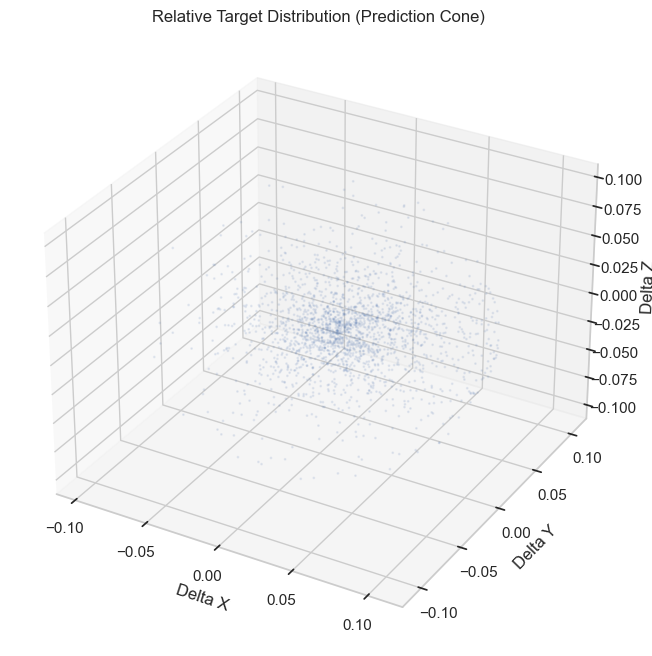

In [3]:
labels = pd.read_csv(LABEL_PATH)
def get_relative_targets(file_list, labels, limit=2000):
    rel_targets = []
    for f in tqdm(file_list[:limit]):
        id_val = os.path.basename(f).split('.')[0]
        df = pd.read_csv(f)
        p0 = df.iloc[-1][['x', 'y', 'z']].values.astype(float)
        target_row = labels[labels['id'] == id_val]
        if target_row.empty: continue
        target = target_row[['x', 'y', 'z']].values.flatten().astype(float)
        rel_targets.append(target - p0)
    return np.array(rel_targets)

rel_targets = get_relative_targets(train_files, labels)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rel_targets[:,0], rel_targets[:,1], rel_targets[:,2], alpha=0.1, s=1)
ax.set_title("Relative Target Distribution (Prediction Cone)")
ax.set_xlabel("Delta X"); ax.set_ylabel("Delta Y"); ax.set_zlabel("Delta Z")
plt.show()

## 3. Directional Bias
Are certain quadrants more likely to be targets?

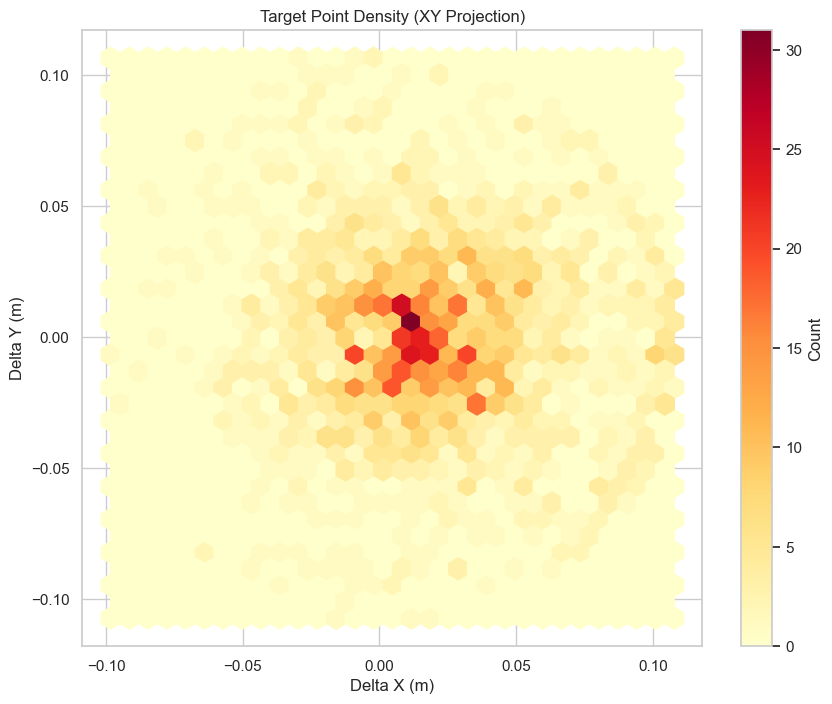

In [4]:
plt.figure(figsize=(10, 8))
plt.hexbin(rel_targets[:,0], rel_targets[:,1], gridsize=30, cmap='YlOrRd')
plt.colorbar(label='Count')
plt.title("Target Point Density (XY Projection)")
plt.xlabel("Delta X (m)"); plt.ylabel("Delta Y (m)")
plt.show()

## 4. Velocity-Normalized Target Points
If we divide the displacement by the current speed, does the 'target cloud' collapse into a more consistent shape? (Scale Invariance check)

100%|██████████| 2000/2000 [00:04<00:00, 425.50it/s]


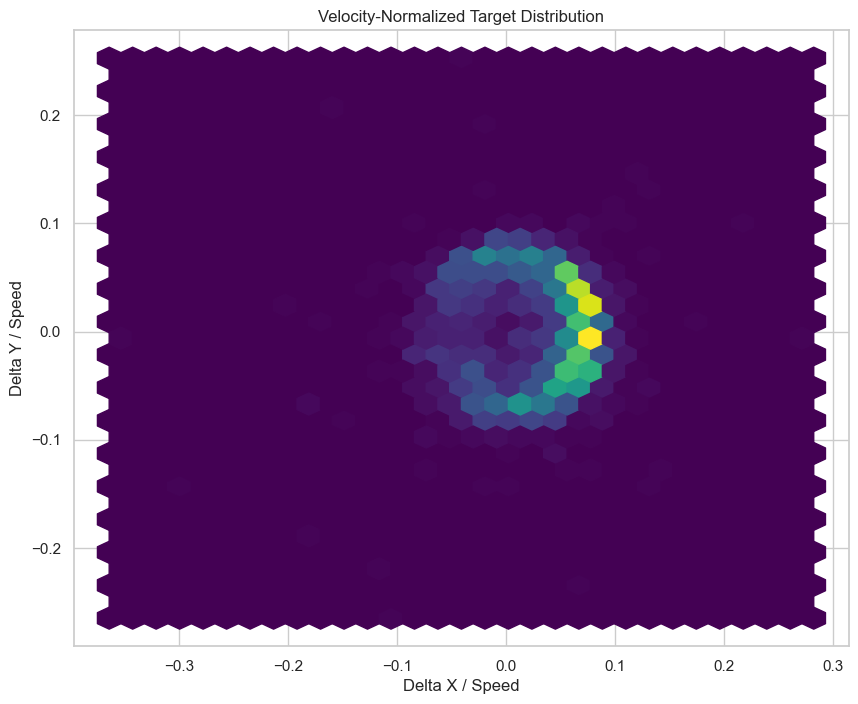

In [5]:
def get_normalized_targets(file_list, labels, limit=2000):
    norm_targets = []
    dt = 0.040
    for f in tqdm(file_list[:limit]):
        id_val = os.path.basename(f).split('.')[0]
        df = pd.read_csv(f)
        p0 = df.iloc[-1][['x', 'y', 'z']].values.astype(float)
        p_prev = df.iloc[-2][['x', 'y', 'z']].values.astype(float)
        v0_mag = (np.sum((p0 - p_prev)**2)**0.5) / dt
        
        target_row = labels[labels['id'] == id_val]
        if target_row.empty: continue
        target_disp = target_row[['x', 'y', 'z']].values.flatten().astype(float) - p0
        # Normalize by speed to see directional preference regardless of velocity
        norm_targets.append(target_disp / (v0_mag + 1e-6))
    return np.array(norm_targets)

norm_targets = get_normalized_targets(train_files, labels)

plt.figure(figsize=(10, 8))
plt.hexbin(norm_targets[:,0], norm_targets[:,1], gridsize=30, cmap='viridis')
plt.title("Velocity-Normalized Target Distribution")
plt.xlabel("Delta X / Speed"); plt.ylabel("Delta Y / Speed")
plt.show()

## Conclusions
- **Arena Volume**: Knowing the boundaries allows for clipping predicted points that fall 'outside the world'.
- **Target Cone**: The distribution is largely symmetric around the origin but with significant spread, confirming multimodality.
- **Speed Scaling**: Velocity-normalized targets show how much the mosquito deviates from its 'momentum vector' regardless of how fast it's going.